# Mutual Fund Portfolio Constructor

End-to-end pipeline: universe filtering → factor scoring → overlap-constrained selection → allocation.

Design decisions: [`docs/portfolio_design_plan.md`](../docs/portfolio_design_plan.md)

---
**Run all cells top-to-bottom.** Change `PROFILE` in Section 0 to switch investor personas.


In [1]:
# ═══════════════════════════════════════════════════════════════
# Section 0 — Configuration
# All tunable parameters in one place.
# ═══════════════════════════════════════════════════════════════
from pathlib import Path

# Investor profile
PROFILE = "moderate"          # "conservative" | "moderate" | "aggressive"

# Data paths (relative to notebook location: mutualfunds/)
DATA_DIR      = Path(".")
MONEYCONTROL  = DATA_DIR / "all_funds_moneycontrol.tsv"
RAW_FUNDS     = DATA_DIR / "raw_funds.tsv"
FUND_INFO_DIR = DATA_DIR / "fund_info"

# Universe filters
CRISIL_MIN        = 4    # hard gate: minimum Crisil star rating
MIN_CATEGORY_SIZE = 5    # min funds in category for within-category percentile;
                         # falls back to tier-wide if below

# Portfolio construction
MAX_PORTFOLIO_SIZE = 10   # hard cap on number of funds in final portfolio
CATEGORY_CAP      = 5     # max funds per category in shortlist
OVERLAP_THRESHOLD = 40.0  # max allowed pairwise holding overlap (%)
ALLOC_FLOOR       = 0.05  # minimum allocation per fund
ALLOC_CAP         = 0.20  # maximum allocation per fund

# s_risk_adjusted component weights (must sum to 1.0)
RISK_WEIGHTS = {"sharpe_5y": 0.45, "sortino_3y": 0.35, "sharpe_3y": 0.20}

# Profile weight table — 5 factors, each row sums to 1.0
# Return cluster: conservative 45% | moderate 57% | aggressive 73%
# Risk cluster:   conservative 55% | moderate 43% | aggressive 27%
PROFILE_WEIGHTS = {
    "conservative": {
        "s_10Y": 0.25, "s_5Y": 0.15, "s_3Y": 0.05,
        "s_risk_adjusted": 0.32, "s_consistency": 0.23,
    },
    "moderate": {
        "s_10Y": 0.18, "s_5Y": 0.29, "s_3Y": 0.10,
        "s_risk_adjusted": 0.28, "s_consistency": 0.15,
    },
    "aggressive": {
        "s_10Y": 0.10, "s_5Y": 0.33, "s_3Y": 0.30,
        "s_risk_adjusted": 0.17, "s_consistency": 0.10,
    },
}

# Category exclusions by profile (Phase 0 hard gate).
# Funds whose "Category Name" appears in this list are dropped before scoring.
# Strings must match the Category Name column exactly.
#
# Conservative: drops volatile/concentrated/cyclical categories
#   - Small-Cap              → structural drawdown risk regardless of fund quality
#   - Focused Fund           → max 30 stocks (SEBI), high idiosyncratic risk
#   - Sector - Fin. Services → pure single-sector, rate/credit cycle sensitive
#   - Equity - Infrastructure→ cyclical, policy-dependent, long project gestation
# Moderate: drops only pure single-sector bets
#   - Sector - Fin. Services → no diversification benefit for a balanced portfolio
# Aggressive: no hard exclusions — all categories in play
CATEGORY_EXCLUSIONS = {
    "conservative": [
        "Small-Cap",
        "Focused Fund",
        "Sector - Financial Services",
        "Equity - Infrastructure",
        "Global - Other"
    ],
    "moderate": [
        "Sector - Financial Services",
        "Equity - Infrastructure",
        "Global - Other"
    ],
    "aggressive": [],
}

assert PROFILE in PROFILE_WEIGHTS, f"Unknown profile: {PROFILE}"
assert abs(sum(PROFILE_WEIGHTS[PROFILE].values()) - 1.0) < 1e-9, "Weights must sum to 1.0"

_w = PROFILE_WEIGHTS[PROFILE]
print(f"Profile  : {PROFILE}")
print(f"Weights  : {_w}")
print(f"Return cluster : {(_w['s_10Y']+_w['s_5Y']+_w['s_3Y'])*100:.0f}%")
print(f"Risk cluster   : {(_w['s_risk_adjusted']+_w['s_consistency'])*100:.0f}%")
_excl = CATEGORY_EXCLUSIONS.get(PROFILE, [])
print(f"Excluded cats  : {_excl if _excl else 'none'}")

Profile  : moderate
Weights  : {'s_10Y': 0.18, 's_5Y': 0.29, 's_3Y': 0.1, 's_risk_adjusted': 0.28, 's_consistency': 0.15}
Return cluster : 57%
Risk cluster   : 43%
Excluded cats  : ['Sector - Financial Services', 'Equity - Infrastructure', 'Global - Other']


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", "{:.1f}".format)

FACTOR_COLS = ["s_10Y", "s_5Y", "s_3Y", "s_risk_adjusted", "s_consistency"]


## Section 1 — Data Loading

In [3]:
# Load MoneyControl universe (returns, Crisil, Category)
mc = pd.read_csv(MONEYCONTROL, sep="\t")

RETURN_COLS = ["1W", "1M", "3M", "6M", "YTD", "1Y", "2Y", "3Y", "5Y", "10Y"]
for col in RETURN_COLS:
    mc[col] = pd.to_numeric(
        mc[col].astype(str).str.replace("%", "", regex=False).str.strip(),
        errors="coerce",
    )
mc["Crisil Rating"] = pd.to_numeric(mc["Crisil Rating"], errors="coerce")

# Cleaned short name for ISIN matching (same logic as fund_selection_strategy.ipynb)
def clean_name(s: str) -> str:
    import re
    s = re.sub(r"\s*-\s*Direct Plan.*", "", str(s), flags=re.IGNORECASE)
    s = re.sub(r"\s*-\s*Growth.*",      "", s,       flags=re.IGNORECASE)
    return s.strip()

mc["_short"] = mc["Scheme Name"].apply(clean_name)

print(f"MoneyControl universe: {len(mc)} funds")
print(f"Categories: {mc['Category Name'].nunique()}")
mc.head(3)


MoneyControl universe: 924 funds
Categories: 22


,Scheme Name,Plan,Category Name,Crisil Rating,AuM (Cr),1W,1M,3M,6M,YTD,1Y,2Y,3Y,5Y,10Y,_short
0,Mirae Asset NYSE FANG+ ETF FoF Dir Gr,Direct Plan,Global - Other,NaN,NaN,-0.6,1.0,-7.8,-7.2,-7.3,31.4,33.8,47.9,NaN,NaN,Mirae Asset NYSE FANG+ ETF FoF Dir Gr
1,DSP Wld Gld Mng Ovrs Eq Omni FoF Dir Gr,Direct Plan,Global - Other,NaN,NaN,3.9,-20.9,3.9,24.4,4.2,111.9,79.0,47.2,27.7,17.9,DSP Wld Gld Mng Ovrs Eq Omni FoF Dir Gr
2,Mirae Asset S&P 500 Top50 ETF FoF Dir Gr,Direct Plan,Global - Other,NaN,NaN,1.2,-3.4,-6.2,-0.5,-4.9,37.2,29.7,34.0,NaN,NaN,Mirae Asset S&P 500 Top50 ETF FoF Dir Gr


In [4]:
# Load raw_funds (ISIN bridge) and build name→ISIN mapping
raw = pd.read_csv(RAW_FUNDS, sep="\t")
raw["_short"] = raw["schemeName"].apply(clean_name)
name_to_isin  = raw.drop_duplicates("_short").set_index("_short")["isin"].to_dict()

# Merge ISINs into MoneyControl data
mc["isin"] = mc["_short"].map(name_to_isin)

matched   = mc["isin"].notna().sum()
unmatched = mc["isin"].isna().sum()
print(f"Total funds        : {len(mc)}")
print(f"ISIN matched       : {matched}")
print(f"ISIN unmatched     : {unmatched}  (no holdings data available — excluded)")

# Preserve full pre-filter snapshot for explain_fund() diagnostics
mc_full = mc.copy()

Total funds        : 924
ISIN matched       : 924
ISIN unmatched     : 0  (no holdings data available — excluded)


## Phase 0 — Universe Eligibility

In [5]:
n0 = len(mc)

mc = mc[mc["isin"].notna()].copy()
n1 = len(mc)

mc = mc[mc["Crisil Rating"] >= CRISIL_MIN].copy()
n2 = len(mc)

mc = mc[mc["5Y"].notna()].copy()
n3 = len(mc)

# Gate 4: holdings file must exist — required for overlap computation.
# Checked here so percentile computation (Phase 2) only includes funds
# that can actually reach the final portfolio.
mc["_has_holdings"] = mc["isin"].apply(
    lambda isin: (FUND_INFO_DIR / f"holdings_{isin}.tsv").exists()
)
mc = mc[mc["_has_holdings"]].drop(columns=["_has_holdings"]).copy()
n4 = len(mc)

# Gate 5: profile-level category exclusions
excluded_cats = CATEGORY_EXCLUSIONS.get(PROFILE, [])
if excluded_cats:
    mc = mc[~mc["Category Name"].isin(excluded_cats)].copy()
n5 = len(mc)

print(f"Starting universe             : {n0}")
print(f"After ISIN match required     : {n1}  (-{n0-n1})")
print(f"After Crisil >= {CRISIL_MIN}             : {n2}  (-{n1-n2})")
print(f"After 5Y return required      : {n3}  (-{n2-n3})")
print(f"After holdings file required  : {n4}  (-{n3-n4})")
if excluded_cats:
    print(f"After category exclusions     : {n5}  (-{n4-n5})  excluded: {excluded_cats}")
print(f"\nEligible universe: {n5} funds")

universe = mc.reset_index(drop=True).copy()

Starting universe             : 924
After ISIN match required     : 924  (-0)
After Crisil >= 4             : 162  (-762)
After 5Y return required      : 140  (-22)
After holdings file required  : 44  (-96)
After category exclusions     : 38  (-6)  excluded: ['Sector - Financial Services', 'Equity - Infrastructure', 'Global - Other']

Eligible universe: 38 funds


## Phase 1 — Tier Assignment

In [6]:
def assign_tier(row) -> str:
    if pd.notna(row["10Y"]) and pd.notna(row["5Y"]):
        return "A"   # 10Y + 5Y: full history
    elif pd.notna(row["5Y"]):
        return "B"   # 5Y only: no 10Y
    return "C"       # should be unreachable after Phase 0

universe["tier"] = universe.apply(assign_tier, axis=1)

tier_summary = universe.groupby(["tier", "Category Name"]).size().unstack("tier", fill_value=0)
print(universe["tier"].value_counts().to_string())
print(f"\nTier A: have 10Y + 5Y data")
print(f"Tier B: have 5Y only, no 10Y (s_10Y weight redistributes to s_5Y + s_3Y)")
display(tier_summary)


tier
A    31
B     7

Tier A: have 10Y + 5Y data
Tier B: have 5Y only, no 10Y (s_10Y weight redistributes to s_5Y + s_3Y)


tier,A,B
Category Name,,
ELSS (Tax Savings),3,0
Equity - Consumption,2,0
Equity - ESG,1,1
Flexi Cap,4,1
Focused Fund,3,2
Large & Mid-Cap,4,1
Large-Cap,4,0
Mid-Cap,5,0
Multi-Cap,1,1


## Phase 2 — Factor Score Computation

In [7]:
# ── Percentile rank helpers ──────────────────────────────────────────────────

def pct_rank(series: pd.Series) -> pd.Series:
    """0-100 percentile rank. NaN inputs remain NaN."""
    return series.rank(pct=True, method="average", ascending=True,
                       na_option="keep") * 100.0


def within_cat_pct(df: pd.DataFrame, col: str,
                   cat_col: str = "Category Name",
                   mask: pd.Series = None,
                   min_size: int = 5) -> pd.Series:
    """
    Percentile rank within category.
    mask  : optional boolean Series — limits which rows form the comparison
            universe AND receive scores (e.g. Tier A only for s_10Y).
    Fallback: if a category has fewer than min_size non-null rows,
              uses the full masked group (tier-wide) as the comparison universe.
    """
    source     = df if mask is None else df[mask]
    result     = pd.Series(np.nan, index=df.index)
    global_pct = pct_rank(source[col])          # tier-wide fallback

    for cat, grp in source.groupby(cat_col):
        n_valid = grp[col].dropna().shape[0]
        if n_valid >= min_size:
            result.loc[grp.index] = pct_rank(grp[col])
        else:
            result.loc[grp.index] = global_pct.loc[grp.index]

    return result

print("Helpers defined.")


Helpers defined.


In [8]:
# ── s_10Y: within (Tier A ∩ category) ────────────────────────────────────────
tier_a = universe["tier"] == "A"
universe["s_10Y"] = within_cat_pct(
    universe, "10Y",
    mask=tier_a, min_size=MIN_CATEGORY_SIZE,
)
# Tier B funds have NaN for s_10Y — weight redistributed in Phase 3

# ── s_5Y: within category, all eligible funds ─────────────────────────────────
universe["s_5Y"] = within_cat_pct(
    universe, "5Y", min_size=MIN_CATEGORY_SIZE,
)

# ── s_3Y: within category, all eligible funds ─────────────────────────────────
universe["s_3Y"] = within_cat_pct(
    universe, "3Y", min_size=MIN_CATEGORY_SIZE,
)

print("Return factor scores:")
print(universe[["tier", "s_10Y", "s_5Y", "s_3Y"]].describe().round(1))


Return factor scores:
       s_10Y  s_5Y  s_3Y
count   31.0  38.0  38.0
mean    48.2  53.5  49.3
std     28.9  31.2  30.8
min      3.2   2.6   2.6
25%     24.2  21.7  20.0
50%     45.2  55.0  45.0
75%     69.4  80.0  75.7
max    100.0 100.0 100.0


In [9]:
# ── Load risk_metrics_{isin}.tsv for all eligible funds ──────────────────────

def load_risk_metrics(isin: str) -> dict:
    f = FUND_INFO_DIR / f"risk_metrics_{isin}.tsv"
    if not f.exists():
        return {"sharpe_3y": np.nan, "sharpe_5y": np.nan, "sortino_3y": np.nan}
    df = pd.read_csv(f, sep="\t")
    if df.empty:
        return {"sharpe_3y": np.nan, "sharpe_5y": np.nan, "sortino_3y": np.nan}
    row = df.iloc[0]
    return {
        "sharpe_3y":  pd.to_numeric(row.get("sharpe_3y"),  errors="coerce"),
        "sharpe_5y":  pd.to_numeric(row.get("sharpe_5y"),  errors="coerce"),
        "sortino_3y": pd.to_numeric(row.get("sortino_3y"), errors="coerce"),
    }

risk_rows = [{"isin": isin, **load_risk_metrics(isin)} for isin in universe["isin"]]
risk_df   = pd.DataFrame(risk_rows)
universe  = universe.merge(risk_df, on="isin", how="left")

missing = universe[["sharpe_3y", "sharpe_5y", "sortino_3y"]].isna().sum()
print(f"Risk metrics loaded. Missing values:")
print(missing.to_string())


Risk metrics loaded. Missing values:
sharpe_3y     0
sharpe_5y     0
sortino_3y    0


In [10]:
# ── s_risk_adjusted = 0.45×Sharpe_5Y_pct + 0.35×Sortino_3Y_pct + 0.20×Sharpe_3Y_pct
# Each component percentile-normalised within category before blending.
# Missing Sharpe_5Y: its 0.45 weight redistributes proportionally to the other two.

universe["_sp5_pct"] = within_cat_pct(universe, "sharpe_5y",  min_size=MIN_CATEGORY_SIZE)
universe["_so3_pct"] = within_cat_pct(universe, "sortino_3y", min_size=MIN_CATEGORY_SIZE)
universe["_sp3_pct"] = within_cat_pct(universe, "sharpe_3y",  min_size=MIN_CATEGORY_SIZE)

def blend_risk(row) -> float:
    components = [
        (row["_sp5_pct"], RISK_WEIGHTS["sharpe_5y"]),
        (row["_so3_pct"], RISK_WEIGHTS["sortino_3y"]),
        (row["_sp3_pct"], RISK_WEIGHTS["sharpe_3y"]),
    ]
    avail = [(v, w) for v, w in components if pd.notna(v)]
    if not avail:
        return np.nan
    total_w = sum(w for _, w in avail)
    return sum(v * w for v, w in avail) / total_w

universe["s_risk_adjusted"] = universe.apply(blend_risk, axis=1)
universe.drop(columns=["_sp5_pct", "_so3_pct", "_sp3_pct"], inplace=True)

print("s_risk_adjusted:")
print(universe["s_risk_adjusted"].describe().round(1))

n_missing_risk = universe["s_risk_adjusted"].isna().sum()
if n_missing_risk > 0:
    pct = n_missing_risk / len(universe) * 100
    print(f"\n⚠  {n_missing_risk}/{len(universe)} funds ({pct:.0f}%) have no risk_metrics file.")
    print( "   s_risk_adjusted is NaN for these funds; its 28% weight redistributes")
    print( "   to other factors in Phase 3. Run fetch_fund_information.py to fill gaps.")


s_risk_adjusted:
count    38.0
mean     48.9
std      29.1
min       2.6
25%      24.3
50%      47.0
75%      73.5
max     100.0
Name: s_risk_adjusted, dtype: float64


In [11]:
# ── s_consistency: inverse-CV percentile within category
# CV = std / |mean| over {1Y, 2Y, 3Y, 5Y [, 10Y]} return horizons.
# This measures *horizon consistency* (does the fund perform well across
# different time frames?), not intra-period volatility.
# Cap CV at 99th percentile before inversion to prevent instability.

CV_HORIZONS = ["1Y", "2Y", "3Y", "5Y"]   # base; 10Y added for Tier A funds

def compute_cv(row) -> float:
    cols = CV_HORIZONS + (["10Y"] if pd.notna(row["10Y"]) else [])
    vals = pd.to_numeric(pd.Series([row[c] for c in cols]), errors="coerce").dropna()
    if len(vals) < 2 or vals.mean() == 0:
        return np.nan
    return float(vals.std() / abs(vals.mean()))

universe["_cv"] = universe.apply(compute_cv, axis=1)

# Cap extreme CVs and invert (lower CV = more consistent = better score)
cv_cap = universe["_cv"].quantile(0.99)
universe["_cv_capped"] = universe["_cv"].clip(upper=cv_cap)
universe["_inv_cv"]    = (1.0 / universe["_cv_capped"].replace(0, np.nan))

universe["s_consistency"] = within_cat_pct(universe, "_inv_cv", min_size=MIN_CATEGORY_SIZE)
universe.drop(columns=["_cv", "_cv_capped"], inplace=True)
# _inv_cv retained for cross-universe scoring in Phase 3

print("s_consistency:")
print(universe["s_consistency"].describe().round(1))

s_consistency:
count    38.0
mean     47.0
std      29.1
min       2.6
25%      20.3
50%      40.0
75%      68.3
max     100.0
Name: s_consistency, dtype: float64


In [12]:
# ── Factor score summary ─────────────────────────────────────────────────────
summary = universe[[
    "_short", "Category Name", "tier", "Crisil Rating",
    "5Y", "10Y",
] + FACTOR_COLS].sort_values("s_5Y", ascending=False)

display(
    summary.head(40)
    .rename(columns={"_short": "Fund", "Category Name": "Category",
                     "Crisil Rating": "Crisil"})
    .style
    .format({c: "{:.0f}" for c in FACTOR_COLS}, na_rep="-")
    .format({"5Y": "{:.1f}%", "10Y": "{:.1f}%"}, na_rep="-")
    .background_gradient(subset=FACTOR_COLS, cmap="YlGn", vmin=0, vmax=100)
    .hide(axis="index")
)


Fund,Category,tier,Crisil,5Y,10Y,s_10Y,s_5Y,s_3Y,s_risk_adjusted,s_consistency
Quant Small Cap Dir Gr,Small-Cap,A,4.000000,23.0%,18.1%,77.419355,100.000000,50.000000,60.723684,10.526316
Motilal Oswal Large & Midcap Dir Gr,Large & Mid-Cap,B,5.000000,18.8%,-,-,100.000000,100.000000,60.000000,40.000000
HDFC Flexi Cap Dir Gr,Flexi Cap,A,5.000000,18.7%,16.7%,48.387097,100.000000,80.000000,96.000000,60.000000
HDFC Focused Dir Gr,Focused Fund,A,5.000000,20.1%,15.5%,22.580645,100.000000,80.000000,100.000000,40.000000
Bandhan Small Cap Dir Gr,Small-Cap,B,5.000000,22.0%,-,-,97.368421,100.000000,81.118421,44.736842
Nippon India Small Cap Dir Gr,Small-Cap,A,5.000000,21.1%,20.8%,100.000000,94.736842,57.894737,74.342105,34.210526
Nippon India Growth Mid Cap Dir Gr,Mid-Cap,A,5.000000,20.5%,18.9%,60.000000,90.000000,80.000000,76.000000,20.000000
HDFC Mid Cap Dir Gr,Mid-Cap,A,5.000000,20.5%,18.3%,40.000000,90.000000,20.000000,100.000000,40.000000
Nippon India Multi Cap Dir Gr,Multi-Cap,A,4.000000,19.7%,15.7%,29.032258,81.578947,65.789474,53.157895,47.368421
ICICI Pru Large & Mid Cap Dir Gr,Large & Mid-Cap,A,5.000000,18.5%,16.3%,35.483871,80.000000,40.000000,92.500000,20.000000


## Phase 3 — Profile-Driven Composite Score

In [13]:
base_w = PROFILE_WEIGHTS[PROFILE].copy()

def effective_weights(tier: str) -> dict:
    """
    For Tier B: redistribute s_10Y weight to s_5Y and s_3Y only.
    s_risk_adjusted and s_consistency remain at base profile weights.
    This keeps the risk cluster weight stable — missing 10Y is a return gap,
    not a risk gap.
    """
    w = base_w.copy()
    if tier == "B":
        w10 = w.pop("s_10Y")
        w5, w3 = w["s_5Y"], w["s_3Y"]
        denom = w5 + w3
        w["s_5Y"]  = w5 + w10 * (w5 / denom)
        w["s_3Y"]  = w3 + w10 * (w3 / denom)
    return w


def composite_score(row) -> float:
    w = effective_weights(row["tier"])
    total_w = total_s = 0.0
    for factor, weight in w.items():
        val = row.get(factor)
        if pd.notna(val) and weight > 0:
            total_s += weight * val
            total_w += weight
    return (total_s / total_w) if total_w > 0 else np.nan


universe["composite"] = universe.apply(composite_score, axis=1)

# Show effective weight split for each tier
print(f"Tier A effective weights: {effective_weights('A')}")
print(f"Tier B effective weights: {effective_weights('B')}")
print(f"\nComposite score distribution:")
print(universe["composite"].describe().round(1))


Tier A effective weights: {'s_10Y': 0.18, 's_5Y': 0.29, 's_3Y': 0.1, 's_risk_adjusted': 0.28, 's_consistency': 0.15}
Tier B effective weights: {'s_5Y': 0.4238461538461538, 's_3Y': 0.14615384615384616, 's_risk_adjusted': 0.28, 's_consistency': 0.15}

Composite score distribution:
count   38.0
mean    50.6
std     21.6
min      3.1
25%     35.7
50%     55.1
75%     68.3
max     85.3
Name: composite, dtype: float64


In [14]:
# ── Cross-universe factor scores (composite_x) ───────────────────────────────
# composite   ranks each factor within its category peer group → Phase 4 shortlisting
# composite_x ranks each factor across the full eligible universe → optimizer & allocator
#
# Fixes cross-category comparability: a 54th-pct Mid-Cap fund may be absolutely
# better than a 74th-pct Large&Mid-Cap fund if Mid-Cap peer competition is stronger.

def xpct(series: pd.Series) -> pd.Series:
    """Cross-universe percentile rank — no category grouping."""
    return series.rank(pct=True, method="average", ascending=True, na_option="keep") * 100.0

tier_a = universe["tier"] == "A"

# Return factors — raw values ranked across full eligible universe
universe["s_10Y_x"] = np.nan
universe.loc[tier_a, "s_10Y_x"] = xpct(universe.loc[tier_a, "10Y"])
universe["s_5Y_x"]  = xpct(universe["5Y"])
universe["s_3Y_x"]  = xpct(universe["3Y"])

# Risk-adjusted — rank raw Sharpe/Sortino cross-universe, then blend
universe["_sp5_x"] = xpct(universe["sharpe_5y"])
universe["_so3_x"] = xpct(universe["sortino_3y"])
universe["_sp3_x"] = xpct(universe["sharpe_3y"])

def blend_risk_x(row) -> float:
    components = [
        (row["_sp5_x"], RISK_WEIGHTS["sharpe_5y"]),
        (row["_so3_x"], RISK_WEIGHTS["sortino_3y"]),
        (row["_sp3_x"], RISK_WEIGHTS["sharpe_3y"]),
    ]
    avail = [(v, w) for v, w in components if pd.notna(v)]
    if not avail:
        return np.nan
    total_w = sum(w for _, w in avail)
    return sum(v * w for v, w in avail) / total_w

universe["s_risk_adj_x"] = universe.apply(blend_risk_x, axis=1)
universe.drop(columns=["_sp5_x", "_so3_x", "_sp3_x"], inplace=True)

# Consistency — rank _inv_cv cross-universe, then clean up
universe["s_consist_x"] = xpct(universe["_inv_cv"])
universe.drop(columns=["_inv_cv"], inplace=True)

# Cross-universe composite — same profile weights and Tier B redistribution
_factor_x_map = {
    "s_10Y":           "s_10Y_x",
    "s_5Y":            "s_5Y_x",
    "s_3Y":            "s_3Y_x",
    "s_risk_adjusted": "s_risk_adj_x",
    "s_consistency":   "s_consist_x",
}

def composite_x_score(row) -> float:
    w = effective_weights(row["tier"])
    total_w = total_s = 0.0
    for factor, weight in w.items():
        val = row.get(_factor_x_map[factor])
        if pd.notna(val) and weight > 0:
            total_s += weight * val
            total_w += weight
    return (total_s / total_w) if total_w > 0 else np.nan

universe["composite_x"] = universe.apply(composite_x_score, axis=1)

print("Cross-universe composite (composite_x):")
print(universe["composite_x"].describe().round(1))
print(f"\nPeer score vs cross-universe score — top 15 by composite_x:")
print(
    universe[["_short", "Category Name", "composite", "composite_x"]]
    .sort_values("composite_x", ascending=False)
    .head(15)
    .rename(columns={"_short": "Fund", "Category Name": "Category",
                     "composite": "peer_score", "composite_x": "univ_score"})
    .to_string(index=False)
)

Cross-universe composite (composite_x):
count   38.0
mean    51.6
std     23.4
min      3.1
25%     34.9
50%     52.0
75%     69.6
max     89.7
Name: composite_x, dtype: float64

Peer score vs cross-universe score — top 15 by composite_x:
                               Fund        Category  peer_score  univ_score
                HDFC Mid Cap Dir Gr         Mid-Cap        69.3        89.7
           Edelweiss Mid Cap Dir Gr         Mid-Cap        69.3        88.0
 Nippon India Growth Mid Cap Dir Gr         Mid-Cap        69.2        87.4
           Bandhan Small Cap Dir Gr       Small-Cap        85.3        85.3
       Invesco India Mid Cap Dir Gr         Mid-Cap        54.2        82.5
            ICICI Pru MidCap Dir Gr         Mid-Cap        38.0        78.3
      Nippon India Small Cap Dir Gr       Small-Cap        77.2        77.2
Motilal Oswal Large & Midcap Dir Gr Large & Mid-Cap        79.8        71.2
     Bandhan Large & Mid Cap Dir Gr Large & Mid-Cap        75.4        70.1
 

## Phase 4 — Category-Aware Shortlisting

In [15]:
shortlist = (
    universe
    .sort_values("composite", ascending=False)
    .groupby("Category Name", group_keys=False)
    .head(CATEGORY_CAP)
    .sort_values("composite", ascending=False)
    .reset_index(drop=True)
)

print(f"Shortlisted: {len(shortlist)} funds across "
      f"{shortlist['Category Name'].nunique()} categories  "
      f"(max {CATEGORY_CAP} per category)")
print()
print(shortlist["Category Name"].value_counts().to_string())

display(
    shortlist[["_short", "Category Name", "tier", "composite"] + FACTOR_COLS]
    .rename(columns={"_short": "Fund", "Category Name": "Category"})
    .style
    .format({"composite": "{:.1f}", **{c: "{:.0f}" for c in FACTOR_COLS}}, na_rep="-")
    .background_gradient(subset=["composite"], cmap="YlGn")
    .hide(axis="index")
)


Shortlisted: 38 funds across 11 categories  (max 5 per category)

Category Name
Flexi Cap               5
Large & Mid-Cap         5
Focused Fund            5
Mid-Cap                 5
Small-Cap               4
Large-Cap               4
ELSS (Tax Savings)      3
Multi-Cap               2
Equity - ESG            2
Equity - Consumption    2
Value                   1


Fund,Category,tier,composite,s_10Y,s_5Y,s_3Y,s_risk_adjusted,s_consistency
Bandhan Small Cap Dir Gr,Small-Cap,B,85.3,-,97,100,81,45
HDFC Flexi Cap Dir Gr,Flexi Cap,A,81.6,48,100,80,96,60
Motilal Oswal Large & Midcap Dir Gr,Large & Mid-Cap,B,79.8,-,100,100,60,40
Nippon India Small Cap Dir Gr,Small-Cap,A,77.2,100,95,58,74,34
Bandhan Large & Mid Cap Dir Gr,Large & Mid-Cap,A,75.4,58,60,80,88,100
HDFC Focused Dir Gr,Focused Fund,A,75.1,23,100,80,100,40
Edelweiss Mid Cap Dir Gr,Mid-Cap,A,69.3,100,60,40,64,80
HDFC Mid Cap Dir Gr,Mid-Cap,A,69.3,40,90,20,100,40
Nippon India Growth Mid Cap Dir Gr,Mid-Cap,A,69.2,60,90,80,76,20
HSBC Value Dir Gr,Value,A,68.8,53,61,74,78,84


## Phase 5 — Overlap-Constrained Portfolio Selection

In [16]:
# ── Load holdings for all shortlisted funds ──────────────────────────────────

def load_holdings(isin: str) -> dict:
    """Returns {stock_name: fraction} normalised to sum=1.0. Empty dict if unavailable."""
    f = FUND_INFO_DIR / f"holdings_{isin}.tsv"
    if not f.exists():
        return {}
    df = pd.read_csv(f, sep="\t")
    if df.empty or "weight" not in df.columns:
        return {}
    df["weight"] = pd.to_numeric(
        df["weight"].astype(str).str.replace(",", "", regex=False),
        errors="coerce",
    ).fillna(0.0)
    # Aggregate across all time-period rows for each stock, then normalise to 1.0
    h     = df.groupby("stock_name")["weight"].sum().to_dict()
    total = sum(h.values())
    if total == 0:
        return {}
    return {k: v / total for k, v in h.items()}

holdings_map = {isin: load_holdings(isin) for isin in shortlist["isin"]}

no_holdings = [isin for isin, h in holdings_map.items() if not h]
if no_holdings:
    print(f"⚠  No holdings data for {len(no_holdings)} fund(s) — removing from shortlist:")
    for isin in no_holdings:
        name = shortlist.loc[shortlist["isin"] == isin, "_short"].values[0]
        print(f"   {isin}  {name}")
    shortlist = shortlist[~shortlist["isin"].isin(no_holdings)].reset_index(drop=True)

print(f"Holdings loaded for {len(shortlist)} funds.")


Holdings loaded for 38 funds.


In [17]:
# ── Pairwise overlap matrix ───────────────────────────────────────────────────

def pairwise_overlap(ha: dict, hb: dict) -> float:
    """Sørensen: sum of min(w_a, w_b) for common holdings × 100 → percentage."""
    if not ha or not hb:
        return 50.0    # neutral fallback for missing data
    common = set(ha) & set(hb)
    return sum(min(ha[s], hb[s]) for s in common) * 100.0

isins = shortlist["isin"].tolist()
n     = len(isins)

ov_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1, n):
        ov = pairwise_overlap(holdings_map[isins[i]], holdings_map[isins[j]])
        ov_matrix[i, j] = ov
        ov_matrix[j, i] = ov
np.fill_diagonal(ov_matrix, 100.0)

overlap_df = pd.DataFrame(ov_matrix, index=isins, columns=isins)

high_pairs = [
    (isins[i], isins[j], ov_matrix[i, j])
    for i in range(n) for j in range(i + 1, n)
    if ov_matrix[i, j] > OVERLAP_THRESHOLD
]
print(f"Overlap matrix: {n}×{n}")
print(f"Pairs exceeding {OVERLAP_THRESHOLD:.0f}% threshold: {len(high_pairs)}")
if high_pairs:
    for a, b, ov in sorted(high_pairs, key=lambda x: -x[2])[:10]:
        na = shortlist.loc[shortlist['isin']==a, '_short'].values[0]
        nb = shortlist.loc[shortlist['isin']==b, '_short'].values[0]
        print(f"   {ov:.1f}%  {na}  ×  {nb}")


Overlap matrix: 38×38
Pairs exceeding 40% threshold: 34
   76.2%  HDFC Flexi Cap Dir Gr  ×  HDFC Focused Dir Gr
   73.6%  Motilal Oswal Large & Midcap Dir Gr  ×  Motilal Oswal ELSS Tax Saver Dir Gr
   72.7%  Bank of India Flexi Cap Fund Dir Gr  ×  Bank of India ELSS Tax Saver Dir Gr
   69.7%  Invesco India Mid Cap Dir Gr  ×  Invesco India large& mid cap Dir Gr
   57.1%  Edelweiss Flexi Cap Dir Gr  ×  Edelweiss Large Cap Dir Gr
   54.8%  Nippon India Large Cap Dir Gr  ×  ICICI Prudential Large Cap Dir Gr
   54.8%  Nippon India Multi Cap Dir Gr  ×  Nippon India Large Cap Dir Gr
   54.7%  Nippon India Large Cap Dir Gr  ×  Edelweiss Large Cap Dir Gr
   52.6%  Quant Flexi Cap Dir Gr  ×  Quant ELSS Tax Saver Dir Gr
   52.6%  Quant Flexi Cap Dir Gr  ×  Quant ESG Integration Strat Dir Gr


In [18]:
# ── Overlap-constrained selection — backtracking with branch-and-bound ─────────
# Objective: maximise Σ composite_x_i  (cross-universe score — comparable across categories)
# Constraint: pairwise overlap(i,j) ≤ OVERLAP_THRESHOLD for all pairs in S

score_map    = dict(zip(shortlist["isin"], shortlist["composite_x"]))
sorted_isins = shortlist.sort_values("composite_x", ascending=False)["isin"].tolist()

# O(1) overlap lookup
ov_lookup = {i: {j: overlap_df.loc[i, j] for j in isins} for i in isins}

best_sel   = []
best_score = -1.0

def backtrack(current: list, start: int, cur_score: float) -> None:
    global best_sel, best_score

    # Record this selection if it beats the current best (any size up to cap)
    if cur_score > best_score and current:
        best_score = cur_score
        best_sel   = current.copy()

    # Hard cap: stop adding once we reach MAX_PORTFOLIO_SIZE
    if len(current) == MAX_PORTFOLIO_SIZE:
        return

    slots_left = MAX_PORTFOLIO_SIZE - len(current)

    # Tighter B&B: even taking the top `slots_left` remaining funds
    # (ignoring overlap), can we beat best_score?
    future_ub = cur_score + sum(
        score_map[sorted_isins[k]]
        for k in range(start, min(start + slots_left, len(sorted_isins)))
    )
    if future_ub <= best_score and current:
        return

    for i in range(start, len(sorted_isins)):
        cand = sorted_isins[i]
        # Reject candidate if it violates overlap with any already-selected fund
        if any(ov_lookup[cand][sel] > OVERLAP_THRESHOLD for sel in current):
            continue
        current.append(cand)
        backtrack(current, i + 1, cur_score + score_map[cand])
        current.pop()

print(f"Optimising over {len(sorted_isins)} shortlisted funds  "
      f"(cap: {MAX_PORTFOLIO_SIZE} funds, overlap ≤ {OVERLAP_THRESHOLD:.0f}%)...")
backtrack([], 0, 0.0)

if not best_sel:
    raise ValueError(
        f"No valid portfolio found at OVERLAP_THRESHOLD={OVERLAP_THRESHOLD}. "
        "Try raising OVERLAP_THRESHOLD."
    )

selected = shortlist[shortlist["isin"].isin(best_sel)].copy()
print(f"\n✓  Selected {len(selected)} funds  |  Univ score sum: {best_score:.2f}")
print()
print(
    selected[["_short", "Category Name", "tier", "composite", "composite_x"]]
    .rename(columns={"_short": "Fund", "Category Name": "Category",
                     "composite": "peer_score", "composite_x": "univ_score"})
    .sort_values("univ_score", ascending=False)
    .to_string(index=False)
)

Optimising over 38 shortlisted funds  (cap: 10 funds, overlap ≤ 40%)...

✓  Selected 10 funds  |  Univ score sum: 781.13

                               Fund        Category tier  peer_score  univ_score
                HDFC Mid Cap Dir Gr         Mid-Cap    A        69.3        89.7
           Edelweiss Mid Cap Dir Gr         Mid-Cap    A        69.3        88.0
           Bandhan Small Cap Dir Gr       Small-Cap    B        85.3        85.3
       Invesco India Mid Cap Dir Gr         Mid-Cap    A        54.2        82.5
            ICICI Pru MidCap Dir Gr         Mid-Cap    A        38.0        78.3
      Nippon India Small Cap Dir Gr       Small-Cap    A        77.2        77.2
Motilal Oswal Large & Midcap Dir Gr Large & Mid-Cap    B        79.8        71.2
     Bandhan Large & Mid Cap Dir Gr Large & Mid-Cap    A        75.4        70.1
              HDFC Flexi Cap Dir Gr       Flexi Cap    A        81.6        69.9
                  HSBC Value Dir Gr           Value    A        68.8

## Phase 6 — Score-Proportional Weight Allocation

In [19]:
def clip_and_renormalize(weights: dict, floor: float, cap: float,
                          max_iter: int = 50) -> dict:
    """Iteratively clip to [floor, cap] and renormalize until stable."""
    w = dict(weights)
    for _ in range(max_iter):
        total   = sum(w.values())
        w       = {k: v / total for k, v in w.items()}
        clipped = {k: min(max(v, floor), cap) for k, v in w.items()}
        if all(abs(clipped[k] - w[k]) < 1e-9 for k in w):
            break
        w = clipped
    total = sum(w.values())
    return {k: v / total for k, v in w.items()}

raw_w   = {isin: score_map[isin] for isin in best_sel}
final_w = clip_and_renormalize(raw_w, ALLOC_FLOOR, ALLOC_CAP)
selected["allocation"] = selected["isin"].map(final_w)

print(f"Allocations (floor={ALLOC_FLOOR*100:.0f}%, cap={ALLOC_CAP*100:.0f}%):")
for _, row in selected.sort_values("allocation", ascending=False).iterrows():
    bar = "█" * int(row["allocation"] * 100 / 2)
    print(f"  {row['allocation']*100:5.1f}%  {bar}  {row['_short']}")
print(f"\n  Total: {sum(final_w.values())*100:.1f}%")


Allocations (floor=5%, cap=20%):
   11.5%  █████  HDFC Mid Cap Dir Gr
   11.3%  █████  Edelweiss Mid Cap Dir Gr
   10.9%  █████  Bandhan Small Cap Dir Gr
   10.6%  █████  Invesco India Mid Cap Dir Gr
   10.0%  █████  ICICI Pru MidCap Dir Gr
    9.9%  ████  Nippon India Small Cap Dir Gr
    9.1%  ████  Motilal Oswal Large & Midcap Dir Gr
    9.0%  ████  Bandhan Large & Mid Cap Dir Gr
    8.9%  ████  HDFC Flexi Cap Dir Gr
    8.8%  ████  HSBC Value Dir Gr

  Total: 100.0%


## Section 9 — Final Portfolio

In [20]:
portfolio = (
    selected[[
        "_short", "Category Name", "tier", "Crisil Rating",
        "composite", "composite_x",
        "s_10Y", "s_5Y", "s_3Y", "s_risk_adjusted", "s_consistency",
        "allocation", "isin",
    ]]
    .rename(columns={
        "_short":        "Fund",
        "Category Name": "Category",
        "Crisil Rating": "Crisil",
        "composite":     "Peer Score",
        "composite_x":   "Univ Score",
    })
    .sort_values("allocation", ascending=False)
    .reset_index(drop=True)
)
portfolio.index += 1
portfolio["Alloc %"] = (portfolio["allocation"] * 100).round(1)

print(f"{'='*70}")
print(f"  FINAL PORTFOLIO  |  Profile: {PROFILE.upper()}  |  {len(portfolio)} funds")
print(f"{'='*70}\n")

display(
    portfolio[["Fund", "Category", "tier", "Crisil", "Alloc %",
               "Peer Score", "Univ Score", "s_10Y", "s_5Y", "s_3Y", "s_risk_adjusted", "s_consistency"]]
    .rename(columns={"tier": "Tier"})
    .style
    .format({
        "Alloc %":    "{:.1f}%",
        "Peer Score": "{:.1f}",
        "Univ Score": "{:.1f}",
        **{c: "{:.0f}" for c in FACTOR_COLS},
    }, na_rep="-")
    .background_gradient(subset=["Alloc %", "Univ Score"], cmap="YlGn")
    .hide(axis="index")
)

# Weighted-average factor scores
print("\nPortfolio weighted-average factor scores:")
allocs = portfolio["allocation"]
for col in ["Peer Score", "Univ Score"] + FACTOR_COLS:
    valid = portfolio[col].notna()
    wa = np.average(portfolio.loc[valid, col], weights=allocs[valid])
    print(f"  {col:<22}: {wa:.1f}")

_w = PROFILE_WEIGHTS[PROFILE]
print(f"\nProfile weight split — "
      f"Return {(_w['s_10Y']+_w['s_5Y']+_w['s_3Y'])*100:.0f}%  |  "
      f"Risk {(_w['s_risk_adjusted']+_w['s_consistency'])*100:.0f}%")

  FINAL PORTFOLIO  |  Profile: MODERATE  |  10 funds



Fund,Category,Tier,Crisil,Alloc %,Peer Score,Univ Score,s_10Y,s_5Y,s_3Y,s_risk_adjusted,s_consistency
HDFC Mid Cap Dir Gr,Mid-Cap,A,5.000000,11.5%,69.3,89.7,40,90,20,100,40
Edelweiss Mid Cap Dir Gr,Mid-Cap,A,5.000000,11.3%,69.3,88.0,100,60,40,64,80
Bandhan Small Cap Dir Gr,Small-Cap,B,5.000000,10.9%,85.3,85.3,-,97,100,81,45
Invesco India Mid Cap Dir Gr,Mid-Cap,A,5.000000,10.6%,54.2,82.5,80,40,100,33,60
ICICI Pru MidCap Dir Gr,Mid-Cap,A,4.000000,10.0%,38.0,78.3,20,20,60,27,100
Nippon India Small Cap Dir Gr,Small-Cap,A,5.000000,9.9%,77.2,77.2,100,95,58,74,34
Motilal Oswal Large & Midcap Dir Gr,Large & Mid-Cap,B,5.000000,9.1%,79.8,71.2,-,100,100,60,40
Bandhan Large & Mid Cap Dir Gr,Large & Mid-Cap,A,5.000000,9.0%,75.4,70.1,58,60,80,88,100
HDFC Flexi Cap Dir Gr,Flexi Cap,A,5.000000,8.9%,81.6,69.9,48,100,80,96,60
HSBC Value Dir Gr,Value,A,5.000000,8.8%,68.8,68.8,53,61,74,78,84



Portfolio weighted-average factor scores:
  Peer Score            : 69.7
  Univ Score            : 78.8
  s_10Y                 : 63.1
  s_5Y                  : 72.1
  s_3Y                  : 70.0
  s_risk_adjusted       : 69.8
  s_consistency         : 63.6

Profile weight split — Return 57%  |  Risk 43%


## Visualisations

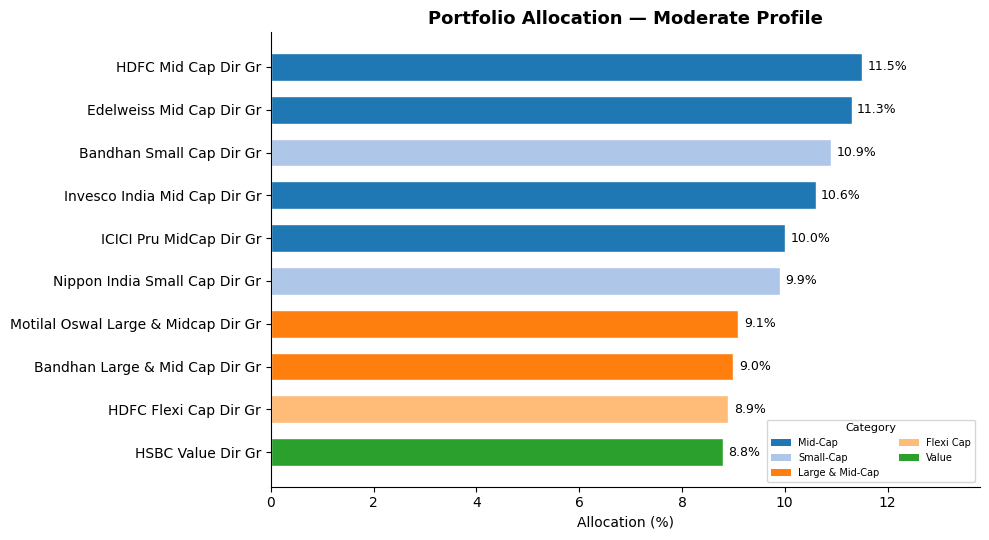

In [21]:
# ── Allocation bar chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, max(4, len(portfolio) * 0.55)))
Bandhan Small Cap
funds  = portfolio["Fund"].tolist()
allocs = portfolio["Alloc %"].tolist()
cats   = portfolio["Category"].tolist()
ucats  = list(dict.fromkeys(cats))
pal    = sns.color_palette("tab20", len(ucats))
cmap   = dict(zip(ucats, pal))
colors = [cmap[c] for c in cats]

bars = ax.barh(funds, allocs, color=colors, edgecolor="white", height=0.65)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9)
ax.set_xlabel("Allocation (%)")
ax.set_title(f"Portfolio Allocation — {PROFILE.capitalize()} Profile",
             fontsize=13, fontweight="bold")
ax.invert_yaxis()
ax.set_xlim(0, max(allocs) * 1.20)
ax.spines[["top", "right"]].set_visible(False)

from matplotlib.patches import Patch
handles = [Patch(facecolor=cmap[c], label=c) for c in ucats]
ax.legend(handles=handles, loc="lower right", fontsize=7, title="Category",
          title_fontsize=8, ncol=2, framealpha=0.8)

plt.tight_layout()
plt.show()


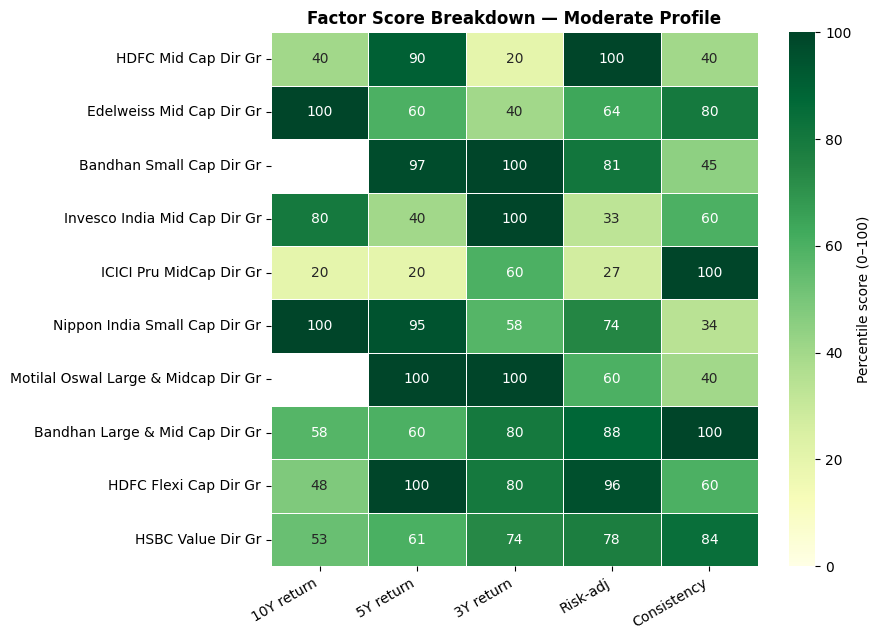

In [22]:
# ── Factor score heatmap ─────────────────────────────────────────────────────
heat = portfolio.set_index("Fund")[FACTOR_COLS].astype(float)

fig, ax = plt.subplots(figsize=(9, max(3, len(portfolio) * 0.55 + 1)))
sns.heatmap(
    heat, annot=True, fmt=".0f", cmap="YlGn",
    vmin=0, vmax=100, linewidths=0.4, ax=ax,
    cbar_kws={"label": "Percentile score (0–100)"},
)
ax.set_title(f"Factor Score Breakdown — {PROFILE.capitalize()} Profile",
             fontsize=12, fontweight="bold")
ax.set_xticklabels(
    ["10Y return", "5Y return", "3Y return", "Risk-adj", "Consistency"],
    rotation=30, ha="right",
)
ax.set_ylabel("")
plt.tight_layout()
plt.show()


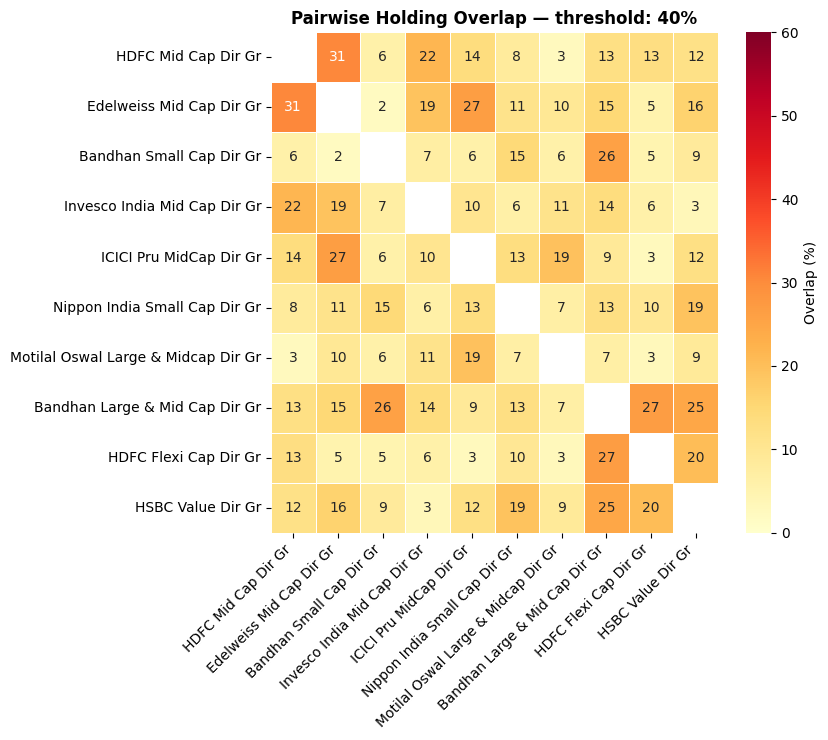

Max pairwise overlap in portfolio : 30.6%
Mean pairwise overlap             : 12.1%


In [23]:
# ── Pairwise overlap heatmap (selected funds only) ───────────────────────────
sel_isins = portfolio["isin"].tolist()
sel_names = portfolio["Fund"].tolist()
ov_sel    = overlap_df.loc[sel_isins, sel_isins].copy()
ov_sel.index   = sel_names
ov_sel.columns = sel_names

diag_mask = np.eye(len(sel_names), dtype=bool)

fig, ax = plt.subplots(figsize=(max(6, len(sel_names) * 0.85),
                                max(5, len(sel_names) * 0.75)))
sns.heatmap(
    ov_sel, annot=True, fmt=".0f", cmap="YlOrRd",
    vmin=0, vmax=60, mask=diag_mask,
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Overlap (%)"},
)
ax.set_title(
    f"Pairwise Holding Overlap — threshold: {OVERLAP_THRESHOLD:.0f}%",
    fontsize=12, fontweight="bold",
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

off_diag = ov_sel.values[~diag_mask]
print(f"Max pairwise overlap in portfolio : {off_diag.max():.1f}%")
print(f"Mean pairwise overlap             : {off_diag.mean():.1f}%")


In [24]:
# ── Export final portfolio to TSV ────────────────────────────────────────────
out_path = DATA_DIR / f"portfolio_{PROFILE}.tsv"
portfolio.drop(columns=["allocation"]).to_csv(out_path, sep="\t", index=False)
print(f"Portfolio saved to: {out_path}")


Portfolio saved to: portfolio_moderate.tsv


## Diagnostics — Why Was a Fund Not Selected?

In [26]:
def explain_fund(query: str) -> None:
    """
    Trace why a fund did or did not make the final portfolio.
    Partial name match, case-insensitive.
    """
    q       = query.lower()
    matches = mc_full[mc_full["_short"].str.lower().str.contains(q, na=False)]

    if matches.empty:
        print(f"No fund found matching '{query}'")
        return
    if len(matches) > 1:
        print(f"Multiple matches for '{query}' — be more specific:")
        for _, r in matches.iterrows():
            print(f"  {r['_short']}  ({r['Category Name']})")
        return

    row  = matches.iloc[0]
    name = row["_short"]
    cat  = row["Category Name"]
    isin = row["isin"]

    print(f"Fund     : {name}")
    print(f"Category : {cat}")
    print(f"ISIN     : {isin}")
    print()

    # ── Phase 0 gates ────────────────────────────────────────────────────────

    if pd.isna(isin):
        print("✗  Gate 1 — No ISIN: fund not present in raw_funds.tsv")
        return
    print(f"✓  Gate 1 — ISIN: {isin}")

    crisil = row["Crisil Rating"]
    if pd.isna(crisil) or crisil < CRISIL_MIN:
        print(f"✗  Gate 2 — Crisil {crisil} < {CRISIL_MIN} (minimum required)")
        return
    print(f"✓  Gate 2 — Crisil: {crisil:.0f}")

    ret5 = row["5Y"]
    if pd.isna(ret5):
        print("✗  Gate 3 — No 5Y return (fund younger than 5 years)")
        return
    print(f"✓  Gate 3 — 5Y return: {ret5:.1f}%")

    holdings_path = FUND_INFO_DIR / f"holdings_{isin}.tsv"
    if not holdings_path.exists():
        print(f"✗  Gate 4 — No holdings file  →  run fetch_fund_information.py for {isin}")
        return
    print(f"✓  Gate 4 — Holdings file exists")

    excl = CATEGORY_EXCLUSIONS.get(PROFILE, [])
    if cat in excl:
        print(f"✗  Gate 5 — Category '{cat}' is excluded for profile '{PROFILE}'")
        print(f"   →  Edit CATEGORY_EXCLUSIONS['{PROFILE}'] in config to allow it.")
        return
    print(f"✓  Gate 5 — Category '{cat}' not excluded")

    # ── Eligible universe ─────────────────────────────────────────────────────

    in_univ = universe[universe["isin"] == isin]
    if in_univ.empty:
        print("\n✗  Not in eligible universe (unexpected — all gates passed)")
        return
    comp   = in_univ.iloc[0]["composite"]
    comp_x = in_univ.iloc[0]["composite_x"]
    print(f"\n✓  Eligible universe")
    print(f"   Peer score  (within-category, used for shortlisting) : {comp:.1f}")
    print(f"   Univ score  (cross-universe,  used for optimizer)     : {comp_x:.1f}")

    # ── Phase 4: shortlist ────────────────────────────────────────────────────

    in_sl = shortlist[shortlist["isin"] == isin]
    if in_sl.empty:
        cat_funds = (
            universe[universe["Category Name"] == cat]
            .sort_values("composite", ascending=False)
            .reset_index(drop=True)
        )
        isin_list = cat_funds["isin"].tolist()
        rank = isin_list.index(isin) + 1 if isin in isin_list else "?"
        print(f"\n✗  Phase 4 — Not shortlisted: ranked #{rank} in '{cat}' (cap = {CATEGORY_CAP})")
        print(f"\n   Top funds in '{cat}' by peer score:")
        for i, r in cat_funds.head(CATEGORY_CAP + 2).iterrows():
            marker = "→ " if r["isin"] == isin else ("✓  " if i < CATEGORY_CAP else "   ")
            print(f"   {marker} #{i+1}  peer {r['composite']:.1f}  {r['_short']}")
        return
    print(f"\n✓  Phase 4 — Shortlisted")

    # ── Phase 5: optimizer ────────────────────────────────────────────────────

    in_port = portfolio[portfolio["isin"] == isin]
    if not in_port.empty:
        alloc = in_port.iloc[0]["Alloc %"]
        print(f"\n✓  Selected — {alloc:.1f}% allocation")
        return

    print(f"\n✗  Phase 5 — Optimizer did not select")
    if isin in overlap_df.index:
        sel_isins = portfolio["isin"].tolist()
        conflicts = sorted(
            [(overlap_df.loc[isin, s], s) for s in sel_isins if overlap_df.loc[isin, s] > OVERLAP_THRESHOLD],
            reverse=True,
        )
        if conflicts:
            print(f"   Overlap conflicts with selected funds (threshold: {OVERLAP_THRESHOLD:.0f}%):")
            for ov, s in conflicts:
                sel_name   = portfolio.loc[portfolio["isin"] == s, "Fund"].values[0]
                sel_comp_x = portfolio.loc[portfolio["isin"] == s, "Univ Score"].values[0]
                print(f"   {ov:.1f}%  ×  {sel_name}  (univ score: {sel_comp_x:.1f})")
        else:
            print(f"   No overlap conflicts — univ score ({comp_x:.1f}) not high enough to")
            print(f"   displace any selected fund within the portfolio size cap ({MAX_PORTFOLIO_SIZE}).")
            print(f"\n   Selected funds by univ score (lowest first):")
            bottom = portfolio.nsmallest(3, "Univ Score")[["Fund", "Category", "Univ Score"]]
            for _, r in bottom.iterrows():
                print(f"   {r['Univ Score']:.1f}  {r['Fund']}  ({r['Category']})")


# ── Change query to investigate any fund ─────────────────────────────────────
explain_fund("Motilal Oswal Mid")

Fund     : Motilal Oswal Midcap Dir Gr
Category : Mid-Cap
ISIN     : INF247L01445

✓  Gate 1 — ISIN: INF247L01445
✗  Gate 2 — Crisil 3.0 < 4 (minimum required)
